Загрузка необходимых библиотек и модулей

In [1]:
import pandas as pd
import numpy as np
import re
import langid
import nltk
import stopwordsiso as stopwords_iso
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import random
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kpolekhina/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kpolekhina/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kpolekhina/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/kpolekhina/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Познакомимся с данными

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Размер train:", train.shape)
print("Размер test:", test.shape)

Размер train: (135309, 4)
Размер test: (165378, 3)


In [4]:
train.head()

,ID,url,title,label
0,0,m.kp.md,"Экс-министр экономики Молдовы - главе МИДЭИ, ц...",0
1,1,www.kp.by,Эта песня стала известна многим телезрителям б...,0
2,2,fanserials.tv,Банши 4 сезон 2 серия Бремя красоты смотреть о...,0
3,3,colorbox.spb.ru,Не Беси Меня Картинки,0
4,4,tula-sport.ru,В Новомосковске сыграют следж-хоккеисты алекси...,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135309 entries, 0 to 135308
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      135309 non-null  int64 
 1   url     135309 non-null  object
 2   title   135308 non-null  object
 3   label   135309 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 4.1+ MB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165378 entries, 0 to 165377
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      165378 non-null  int64 
 1   url     165378 non-null  object
 2   title   165378 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.8+ MB


In [7]:
train.label.value_counts()  # оценим баланс классов

label
0    118594
1     16715
Name: count, dtype: int64

In [8]:
# проверим, какие языки присутствуют в наших обучающих данных
train['lang'] = train['title'].fillna("").apply(lambda x: langid.classify(x)[0])
train['lang'].value_counts()

lang
ru    102708
en      9228
bg      4978
uk      3699
sr      2003
       ...  
ml         2
pa         1
gu         1
te         1
ug         1
Name: count, Length: 94, dtype: int64

Предобработка

In [9]:
# возьмём 5 самых популярных языков в тренировочных данных и создадим общий словарь стоп-слов для них
stop_words = set()
stop_words.update(stopwords.words('russian'))
stop_words.update(stopwords.words('english'))

bulgarian_stop = stopwords_iso.stopwords("bg")
ukrainian_stop = stopwords_iso.stopwords("uk")
serbian_stop = stopwords_iso.stopwords("sr")

stop_words.update(bulgarian_stop)
stop_words.update(ukrainian_stop)
stop_words.update(serbian_stop)

In [10]:
def clean_text(text):  # удалим протоколы, поддомены и прочие ненужные элементы
    text = text.lower()
    text = re.sub(r"https?|www|\.com|\.ru|\.org|\.net|\.html|\.php|\.jsp", " ", text)
    text = re.sub(r"[^a-z0-9а-яё ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [11]:
# Объединяем url и title в один текстовый признак
train['text'] = train['url'].fillna('') + ' ' + train['title'].fillna('')
test['text'] = test['url'].fillna('') + ' ' + test['title'].fillna('')

Попробуем два подхода: очистка текста до удаления стоп слов и наборот

In [12]:
def stopwords_then_clean(text):
    text = text.lower()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    joined = " ".join(tokens)
    return clean_text(joined)


In [13]:
def clean_then_stopwords(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)


Была идея применить аугментацию для балансировки классов (так как целевых данных (с меткой 1) сильно меньше, чем нормальных) и разделить на тренировчноую и валидационную выборки, но готовые аугментаторы есть только для английского, поэтому...

Появилась идея создать словарь ключевых для классификации слов (если вы понимаете, о чём я...) для пяти самых популярных в датасете языков вручную, прости господи... потому что WordNet - вещь более академическая
Но потом пришло осознание, что создать достойный словарь это огромная ручная работа, а нам надо что-то менее накрученное.. но удалять я ничего не стала :)

In [14]:
# nsfw_custom_dict = {
#     # English
#     "porn": ["xxx", "adult", "hardcore", "pornhub", "sex"],
#     "nude": ["naked", "topless", "bare"],
#     "boobs": ["tits", "breasts", "melons"],
#     "milf": ["mom", "mature", "stepmom"],
#     "anal": ["butt", "backdoor", "rear"],
#     "fuck": ["f***", "fuk", "fck"],
#     "cam": ["webcam", "camgirl", "livecam"],
#     "video": ["clip", "scene", "stream", "vid"],
#     "live": ["stream", "real-time"],

#     # Russian
#     "порно": ["секс", "видео", "эротика", "порнуха"],
#     "голая": ["обнажённая", "ню", "без одежды"],
#     "грудь": ["сиськи", "тити", "бюст", "персики"],
#     "жопа": ["задница", "ягодицы", "анус", "попа"],
#     "минет": ["оральный", "отсос", "глубокий горловой"],

#     # Bulgarian
#     "порно": ["секс", "еротика", "видео"],
#     "голи": ["разсъблечени", "ню", "без дрехи"],
#     "цици": ["гърди", "бюст", "сиси"],

#     # Ukrainian
#     "порно": ["еротика", "оголені", "доросле відео"],
#     "гола": ["оголена", "ню", "без одягу"],
#     "грудь": ["сиcьки", "перса", "бюст"],
#     "секс": ["інтим", "спокуса"],

#     # Serbian
#     "порнић": ["порно", "еротика"],
#     "гола": ["разголишена", "без одеће", "ню"],
#     "сисе": ["груди", "тити", "бујне груди"],
#     "секc": ["интимно", "водити љубав", "жестоко"],
# }


Далее идут функции, которые планировалось использовать для аугментации синонимами, но они не были задействованы в итоговой модели

In [15]:
# def get_combined_synonyms(word):
#     word_lc = word.lower()
    
#     # сначала пробуем взять из кастомного словаря
#     if word_lc in nsfw_custom_dict:
#         return nsfw_custom_dict[word_lc]

#     # потом через WordNet (только для английского)
#     synonyms = set()
#     for syn in wordnet.synsets(word_lc):
#         for lemma in syn.lemmas():
#             syn_word = lemma.name().replace('_', ' ')
#             if syn_word.lower() != word_lc:
#                 synonyms.add(syn_word)
#     return list(synonyms)


In [16]:
# def augment_with_synonyms(text, n_replacements=2):
#     words = text.split()
#     new_words = words.copy()
    
#     random.shuffle(new_words)  # перемешаем, чтобы рандомно выбирать
    
#     replaced = 0
#     for i, word in enumerate(new_words):
#         synonyms = get_synonyms(word)
#         if synonyms:
#             new_words[i] = random.choice(synonyms)
#             replaced += 1
#         if replaced >= n_replacements:
#             break
    
#     return " ".join(new_words)

In [17]:
X_text = train['text'].fillna("")
y = train['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

# аугментация только для целевых примеров
# X_pos = X_train_raw[y_train == 1]
# y_pos = y_train[y_train == 1]

# X_pos_aug = X_pos.apply(augment_with_synonyms)

# X_train_all = pd.concat([X_train_raw, X_pos_aug])
# y_train_all = pd.concat([y_train, y_pos])

X_train_a = X_train_raw.apply(stopwords_then_clean) # "a" обозначает подход, при котором мы сначала удаляем стоп слова, а потом применяем очистку текста от лишних элементов
X_test_a = X_test_raw.apply(stopwords_then_clean)

X_train_b = X_train_raw.apply(clean_then_stopwords) # "a" обозначает подход, в котором удаление стопслов происходит после очистки текста
X_test_b = X_test_raw.apply(clean_then_stopwords)


Векторизация:

Сначала будем пробовать токенизацию по символам, а не по словам, в надежде лучше отловить более специфичные связи

In [18]:
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 6),
    max_features=30000,
    sublinear_tf=True
)

Сначала забыла добавить балансировку классов в логреге, но получилось всё равно неплохо

In [19]:
# вариант А
X_train_vec_a = vectorizer.fit_transform(X_train_a)
X_test_vec_a = vectorizer.transform(X_test_a)

model_a = LogisticRegression(max_iter=1000, random_state=42)
model_a.fit(X_train_vec_a, y_train)

y_pred_a = model_a.predict(X_test_vec_a)
f1_a = f1_score(y_test, y_pred_a)
print(f"F1-score (stopwords_then_clean): {f1_a:.4f}")

# вариант B
X_train_vec_b = vectorizer.fit_transform(X_train_b)
X_test_vec_b = vectorizer.transform(X_test_b)

model_b = LogisticRegression(max_iter=1000, random_state=42)
model_b.fit(X_train_vec_b, y_train)

y_pred_b = model_b.predict(X_test_vec_b)
f1_b = f1_score(y_test, y_pred_b)
print(f"F1-score (clean_then_stopwords): {f1_b:.4f}")

F1-score (stopwords_then_clean): 0.9629
F1-score (clean_then_stopwords): 0.9682


Добавила балансировку классов, получилось получше!

In [20]:
# вариант А
X_train_vec_a = vectorizer.fit_transform(X_train_a)
X_test_vec_a = vectorizer.transform(X_test_a)

model_a = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_a.fit(X_train_vec_a, y_train)

y_pred_a = model_a.predict(X_test_vec_a)
f1_a = f1_score(y_test, y_pred_a)
print(f"F1-score (stopwords_then_clean): {f1_a:.4f}")

# вариант B
X_train_vec_b = vectorizer.fit_transform(X_train_b)
X_test_vec_b = vectorizer.transform(X_test_b)

model_b = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_b.fit(X_train_vec_b, y_train)

y_pred_b = model_b.predict(X_test_vec_b)
f1_b = f1_score(y_test, y_pred_b)
print(f"F1-score (clean_then_stopwords): {f1_b:.4f}")

F1-score (stopwords_then_clean): 0.9731
F1-score (clean_then_stopwords): 0.9743


Получили буст аж в одну сотую с подходом удаления стопслов после очисти текста!🤯😁 Берём в работу его)

Чувствуется потенциал для улучшения результатов.. Попробуем загридсёрчить и найти параметры векторайзера и логрега, которые в тандеме дадут результат лучше того, что получили при минимальной настройке!

In [21]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

param_grid = {
    'tfidf__ngram_range': [(3, 6), (2, 5), (4, 7)],
    'tfidf__max_features': [20000, 30000, 40000],
    'tfidf__sublinear_tf': [True],
    'tfidf__min_df': [1, 3],
    'clf__C': [0.1, 0.3, 1.0],
    'clf__solver': ['liblinear', 'saga']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_b, y_train)

print("Best F1-score:", grid.best_score_)
print("Best params:", grid.best_params_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=20000, tfidf__min_df=1, tfidf__ngram_range=(4, 7), tfidf__sublinear_tf=True; total time=  13.4s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=20000, tfidf__min_df=1, tfidf__ngram_range=(4, 7), tfidf__sublinear_tf=True; total time=  13.9s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=20000, tfidf__min_df=1, tfidf__ngram_range=(4, 7), tfidf__sublinear_tf=True; total time=  13.9s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=20000, tfidf__min_df=1, tfidf__ngram_range=(3, 6), tfidf__sublinear_tf=True; total time=  15.1s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=20000, tfidf__min_df=1, tfidf__ngram_range=(3, 6), tfidf__sublinear_tf=True; total time=  15.1s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=20000, tfidf__min_df=1, tfidf__ngram_range=(3, 6), tfidf__sublinear_tf=Tr

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=40000, tfidf__min_df=1, tfidf__ngram_range=(3, 6), tfidf__sublinear_tf=True; total time=  14.5s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=40000, tfidf__min_df=1, tfidf__ngram_range=(3, 6), tfidf__sublinear_tf=True; total time=  14.7s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=40000, tfidf__min_df=1, tfidf__ngram_range=(3, 6), tfidf__sublinear_tf=True; total time=  14.7s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=40000, tfidf__min_df=1, tfidf__ngram_range=(4, 7), tfidf__sublinear_tf=True; total time=  13.4s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=40000, tfidf__min_df=1, tfidf__ngram_range=(4, 7), tfidf__sublinear_tf=True; total time=  13.6s
[CV] END clf__C=0.1, clf__solver=liblinear, tfidf__max_features=40000, tfidf__min_df=1, tfidf__ngram_range=(4, 7), tfidf__sublinear_tf=True; total time=  13.6s
[CV] END clf__C=0.1, clf__solver=libline

Очень неплохо, первая попытка засабмитить!) (закомментировали для того, чтобы submission был из другой модели)

In [22]:
# X_final_test = test['text'].fillna("").apply(clean_then_stopwords)

# y_final_pred = grid.best_estimator_.predict(X_final_test)

# submission = pd.DataFrame({
#     'ID': test['ID'],
#     'label': y_final_pred
# })

# submission.to_csv("submission.csv", index=False)

Но всё же можно лучше.. попробуем проанализировать ошибки?

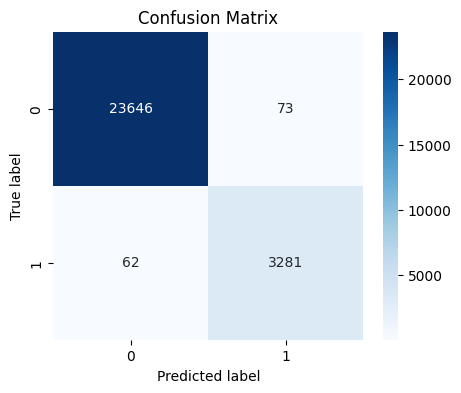

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23719
           1       0.98      0.98      0.98      3343

    accuracy                           1.00     27062
   macro avg       0.99      0.99      0.99     27062
weighted avg       1.00      1.00      1.00     27062



In [23]:
y_pred = grid.best_estimator_.predict(X_test_b)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

Какие приятные результаты.. взглянем, что попало в FN 👀

In [24]:
y_pred = grid.best_estimator_.predict(X_test_b)

X_test_raw = X_test_raw.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
y_pred = pd.Series(y_pred, index=y_test.index)

# маска для FN
fn_mask = (y_test == 1) & (y_pred == 0)

# датафрейм с ошибками
false_negatives = X_test_raw[fn_mask].copy()
false_negatives.name = 'text'
false_negatives = false_negatives.to_frame()
false_negatives['y_true'] = y_test[fn_mask].values
false_negatives['y_pred'] = y_pred[fn_mask].values

false_negatives

,text,y_true,y_pred
1024,spac1.com Rosie_Danvers_-_(Pinup).mp4,1,0
1359,mail.ru секс с выпившей - 77 тыс. результатов....,1,0
1821,svs-games.com Jane - The Office Slut,1,0
2037,mail.ru секс старым бабушкой - 102 тыс. картин...,1,0
3798,kinosalo.org Раздолбанные половые губы девушка...,1,0
...,...,...,...
25571,erotikstories.ru Закрытая школа часть 2.,1,0
25606,hotexamples.com SoapFault PHP Code-Beispiele -...,1,0
26069,www.videogsm.ru Страж Obzor E800A-WiFi,1,0
26622,it.tattooimages.biz Tatuaggio di inchiostro ne...,1,0


Классический pron🫠 выискивать фичи вручную - не вариант.. попробуем перебрать разные векторизаторы и, если что, объединить в лёгенький ансамблик :)

In [25]:
vectorizers = {
    'char_wb': TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 6), max_features=30000),
    'char': TfidfVectorizer(analyzer='char', ngram_range=(3, 6), max_features=30000),
    'word': TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=30000),
    'count_word': CountVectorizer(analyzer='word', ngram_range=(1, 2), max_features=30000),
    'count_char': CountVectorizer(analyzer='char', ngram_range=(3, 6), max_features=30000),
}

results = {}

for name, vec in vectorizers.items():
    print(name)

    pipeline = Pipeline([
        ('vec', vec),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])
    
    pipeline.fit(X_train_b, y_train)
    y_pred = pipeline.predict(X_test_b)
    f1 = f1_score(y_test, y_pred)
    results[name] = f1
    print(f"{name} F1-score: {f1:.4f}")

print("\nРезультаты:")
for name, f1 in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name}: {f1:.4f}")

char_wb
char_wb F1-score: 0.9759
char
char F1-score: 0.9784
word
word F1-score: 0.9648
count_word
count_word F1-score: 0.9652
count_char
count_char F1-score: 0.9816

Результаты:
count_char: 0.9816
char: 0.9784
char_wb: 0.9759
count_word: 0.9652
word: 0.9648


Эх, вы только посмотрите.. просто новая векторизация дала сразу результат лучше моей настроенное модельки.. Ну оно и не очень то удивительно, ведь TfIdf гасит наиболее частотные n-граммы, что может быть невыгодной стратегией для нас.. Ну, исправляюсь!)

In [26]:
count_char_vec = CountVectorizer(analyzer='char', ngram_range=(3, 6), max_features=30000)

count_pipeline = Pipeline([
    ('vec', count_char_vec),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

count_param_grid = {
    'clf__C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'clf__solver': ['liblinear', 'saga']
}

count_grid = GridSearchCV(count_pipeline, count_param_grid, scoring='f1', cv=3, verbose=2, n_jobs=-1)
count_grid.fit(X_train_b, y_train)

print(f"\nBest F1-score: {count_grid.best_score_}")
print(f"Best params: {count_grid.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END ..................clf__C=0.1, clf__solver=liblinear; total time=  33.7s
[CV] END ..................clf__C=0.1, clf__solver=liblinear; total time=  34.7s
[CV] END ..................clf__C=0.5, clf__solver=liblinear; total time=  34.7s
[CV] END ..................clf__C=0.1, clf__solver=liblinear; total time=  35.1s
[CV] END ..................clf__C=0.5, clf__solver=liblinear; total time=  36.1s
[CV] END ..................clf__C=0.5, clf__solver=liblinear; total time=  36.7s
[CV] END ..................clf__C=1.0, clf__solver=liblinear; total time=  32.6s
[CV] END ..................clf__C=1.0, clf__solver=liblinear; total time=  31.8s
[CV] END ..................clf__C=1.0, clf__solver=liblinear; total time=  32.4s
[CV] END ..................clf__C=2.0, clf__solver=liblinear; total time=  31.7s
[CV] END ..................clf__C=2.0, clf__solver=liblinear; total time=  31.0s
[CV] END ..................clf__C=2.0, clf__solv

/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END .......................clf__C=0.1, clf__solver=saga; total time= 2.6min


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not c

[CV] END .......................clf__C=0.5, clf__solver=saga; total time= 2.8min
[CV] END .......................clf__C=0.5, clf__solver=saga; total time= 2.8min
[CV] END .......................clf__C=0.1, clf__solver=saga; total time= 2.8min
[CV] END .......................clf__C=0.1, clf__solver=saga; total time= 2.8min
[CV] END .......................clf__C=0.5, clf__solver=saga; total time= 2.8min
[CV] END ..................clf__C=5.0, clf__solver=liblinear; total time=  34.1s


...

[CV] END .......................clf__C=1.0, clf__solver=saga; total time= 2.8min
[CV] END ..................clf__C=5.0, clf__solver=liblinear; total time=  31.7s
[CV] END ..................clf__C=5.0, clf__solver=liblinear; total time=  32.3s
[CV] END .......................clf__C=1.0, clf__solver=saga; total time= 2.8min
[CV] END .......................clf__C=1.0, clf__solver=saga; total time= 2.8min


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .......................clf__C=2.0, clf__solver=saga; total time= 2.5min
[CV] END .......................clf__C=2.0, clf__solver=saga; total time= 2.5min
[CV] END .......................clf__C=2.0, clf__solver=saga; total time= 2.5min


/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/kpolekhina/Documents/vscode/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .......................clf__C=5.0, clf__solver=saga; total time= 1.9min
[CV] END .......................clf__C=5.0, clf__solver=saga; total time= 1.9min
[CV] END .......................clf__C=5.0, clf__solver=saga; total time= 1.9min

Best F1-score: 0.9827834529944663
Best params: {'clf__C': 5.0, 'clf__solver': 'liblinear'}


Проверим качество ✨ансамбля✨ и будем выбирать окончательную модель!

In [27]:
proba_tfidf = grid.best_estimator_.predict_proba(X_test_b)[:, 1]
proba_count = count_grid.best_estimator_.predict_proba(X_test_b)[:, 1]

proba_avg = (proba_tfidf + proba_count) / 2

y_pred_ensemble = (proba_avg > 0.5).astype(int)

f1_ensemble = f1_score(y_test, y_pred_ensemble)
print(f"F1-score (ensemble tfidf + count): {f1_ensemble:.4f}")

F1-score (ensemble tfidf + count): 0.9831


Попробуем поподбирать порог...

In [28]:
thresholds = np.linspace(0.3, 0.7, 100)
f1_scores = []

for t in thresholds:
    y_pred_thresh = (proba_avg > t).astype(int)
    score = f1_score(y_test, y_pred_thresh)
    f1_scores.append(score)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best F1-score: {best_f1:.4f} at threshold = {best_threshold:.2f}")

Best F1-score: 0.9842 at threshold = 0.53


😍
Последняя попытка построить модель для этой задачи и будем выбирать итоговую:

In [29]:
combined_vectorizer = FeatureUnion([
    ('count_char', CountVectorizer(analyzer='char', ngram_range=(3, 6), max_features=30000)),
    ('tfidf_char', TfidfVectorizer(analyzer='char', ngram_range=(3, 6), max_features=30000)),
])

combined_vectorizer_pipeline = Pipeline([
    ('vec', combined_vectorizer),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

combined_vectorizer_param_grid = {
    'clf__C': [0.5, 1.0, 2.0, 5.0],
    'clf__solver': ['liblinear']
}

combined_vectorizer_param_gridgrid = GridSearchCV(combined_vectorizer_pipeline, combined_vectorizer_param_grid, scoring='f1', cv=3, verbose=2, n_jobs=-1)
combined_vectorizer_param_gridgrid.fit(X_train_b, y_train)

print(f"\nFeatureUnion Best F1-score (CV): {combined_vectorizer_param_gridgrid.best_score_:.4f}")
print(f"Best params: {combined_vectorizer_param_gridgrid.best_params_}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ..................clf__C=0.5, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=1.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=0.5, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=2.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=1.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=0.5, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=2.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=1.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=5.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=2.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=5.0, clf__solver=liblinear; total time= 1.2min
[CV] END ..................clf__C=5.0, clf__solve

Не оно))))

Тогда останавливаемся на proba_avg = (proba_tfidf + proba_count) / 2!

In [30]:
X_final_test = test['text'].fillna("").apply(clean_then_stopwords)

proba_tfidf_final = grid.best_estimator_.predict_proba(X_final_test)[:, 1]
proba_count_final = count_grid.best_estimator_.predict_proba(X_final_test)[:, 1]

proba_avg_final = (proba_tfidf_final + proba_count_final) / 2

y_final_pred = (proba_avg_final > 0.53).astype(int)

submission = pd.DataFrame({
    'ID': test['ID'],
    'label': y_final_pred
})

submission.to_csv("submission.csv", index=False)

Осталось смочь запушить...